In [1]:
!kaggle datasets download -d surajghuwalewala/ham1000-segmentation-and-classification

Dataset URL: https://www.kaggle.com/datasets/surajghuwalewala/ham1000-segmentation-and-classification
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
100%|█████████████████████████████████████▉| 2.59G/2.59G [01:50<00:00, 27.0MB/s]
100%|██████████████████████████████████████| 2.59G/2.59G [01:50<00:00, 25.2MB/s]


In [2]:
import zipfile

# Unzip the dataset
with zipfile.ZipFile('ham1000-segmentation-and-classification.zip', 'r') as zip_ref:
    zip_ref.extractall('ham10000_data')

In [3]:
import pandas as pd
import numpy as np
import os
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [4]:
# Path to the extracted dataset
data_path = 'ham10000_data/'

# Load GroundTruth.csv
df = pd.read_csv(os.path.join(data_path, 'GroundTruth.csv'))

# Display the first few rows
print(df.head())

          image  MEL   NV  BCC  AKIEC  BKL   DF  VASC
0  ISIC_0024306  0.0  1.0  0.0    0.0  0.0  0.0   0.0
1  ISIC_0024307  0.0  1.0  0.0    0.0  0.0  0.0   0.0
2  ISIC_0024308  0.0  1.0  0.0    0.0  0.0  0.0   0.0
3  ISIC_0024309  0.0  1.0  0.0    0.0  0.0  0.0   0.0
4  ISIC_0024310  1.0  0.0  0.0    0.0  0.0  0.0   0.0


In [5]:
# Path to the images folder
image_folder = os.path.join(data_path, 'images')  # Ensure the correct path

# Preprocessing function: grayscale conversion, resizing, normalization
def preprocess_image(image_path, img_size=(128, 128)):
    img = cv2.imread(image_path)  # Read the image
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)  # Convert to grayscale
    img = cv2.resize(img, img_size)  # Resize image
    img = img / 255.0  # Normalize pixel values to [0, 1]
    return img

# Filter rows where the MEL column is 1 (melanoma images)
melanoma_df = df[df['MEL'] == 1]

# Preprocess and store melanoma images
melanoma_images = []
for img_file in melanoma_df['image']:
    img_path = os.path.join(image_folder, img_file + '.jpg')  # Adjust extension if necessary
    melanoma_images.append(preprocess_image(img_path))

# Convert to numpy array
melanoma_images = np.array(melanoma_images)
print(f"Shape of melanoma images: {melanoma_images.shape}")


Shape of melanoma images: (1113, 128, 128)


In [6]:
import tensorflow as tf
from tensorflow.keras import Model, layers
from tensorflow.keras.callbacks import Callback
import os
from tensorflow.keras.preprocessing.image import array_to_img

# Define the Generator model
class Generator(Model):
    def __init__(self):
        super(Generator, self).__init__()
        self.dense = layers.Dense(131072, activation='relu')  # 128*128*1
        self.reshape = layers.Reshape((32, 32, 128))  # Adjust as necessary
        self.conv1 = layers.Conv2DTranspose(64, (3, 3), strides=2, padding='same', activation='relu')
        self.conv2 = layers.Conv2DTranspose(1, (3, 3), strides=2, padding='same', activation='sigmoid')  # Final output

    def call(self, inputs):
        x = self.dense(inputs)
        x = self.reshape(x)
        x = self.conv1(x)
        x = self.conv2(x)  # Final layer for 128x128
        return x

# Define the Discriminator model
class Discriminator(Model):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.conv1 = layers.Conv2D(64, (3, 3), strides=2, padding='same', activation='relu')
        self.conv2 = layers.Conv2D(128, (3, 3), strides=2, padding='same', activation='relu')
        self.flatten = layers.Flatten()
        self.dense = layers.Dense(1, activation='sigmoid')  # Expecting output from flatten

    def call(self, inputs):
        x = self.conv1(inputs)
        x = self.conv2(x)
        x = self.flatten(x)
        return self.dense(x)

# Instantiate the models
generator = Generator()
discriminator = Discriminator()

# Define the MelanomaGAN class
class MelanomaGAN(Model):
    def __init__(self, generator, discriminator, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.generator = generator
        self.discriminator = discriminator

    def compile(self, g_opt, d_opt, g_loss, d_loss, *args, **kwargs):
        super().compile(*args, **kwargs)
        self.g_opt = g_opt
        self.d_opt = d_opt
        self.g_loss = g_loss
        self.d_loss = d_loss

    def train_step(self, batch):
        real_images = batch
        batch_size = tf.shape(batch)[0]
        noise = tf.random.normal([batch_size, 128])

        # Generate fake images using the generator
        fake_images = self.generator(noise)

        # Train the discriminator
        with tf.GradientTape() as d_tape:
            real_output = self.discriminator(real_images)
            fake_output = self.discriminator(fake_images)
            d_loss_real = self.d_loss(tf.ones_like(real_output), real_output)
            d_loss_fake = self.d_loss(tf.zeros_like(fake_output), fake_output)
            d_loss = (d_loss_real + d_loss_fake) / 2

        # Apply gradients for the discriminator
        d_gradients = d_tape.gradient(d_loss, self.discriminator.trainable_variables)
        self.d_opt.apply_gradients(zip(d_gradients, self.discriminator.trainable_variables))

        # Train the generator
        with tf.GradientTape() as g_tape:
            generated_images = self.generator(noise)
            fake_output = self.discriminator(generated_images)
            g_loss = self.g_loss(tf.ones_like(fake_output), fake_output)

        # Apply gradients for the generator
        g_gradients = g_tape.gradient(g_loss, self.generator.trainable_variables)
        self.g_opt.apply_gradients(zip(g_gradients, self.generator.trainable_variables))

        return {"d_loss": d_loss, "g_loss": g_loss}

# Instantiate the MelanomaGAN class
melanoma_gan = MelanomaGAN(generator, discriminator)

# Compile the model
g_opt = tf.keras.optimizers.Adam(1e-4)
d_opt = tf.keras.optimizers.Adam(1e-5)
g_loss = tf.keras.losses.BinaryCrossentropy()
d_loss = tf.keras.losses.BinaryCrossentropy()
melanoma_gan.compile(g_opt, d_opt, g_loss, d_loss)

# Define the custom callback for monitoring
class MelanomaModelMonitor(Callback):
    def __init__(self, num_img=3, latent_dim=128):
        self.num_img = num_img
        self.latent_dim = latent_dim
        # Create the directory if it doesn't exist
        os.makedirs('generated_melanoma_images', exist_ok=True)

    def on_epoch_end(self, epoch, logs=None):
        random_latent_vectors = tf.random.normal((self.num_img, self.latent_dim))
        generated_images = self.model.generator(random_latent_vectors)
        generated_images *= 255
        generated_images = tf.clip_by_value(generated_images, 0, 255)  # Ensure values are in the right range
        generated_images = generated_images.numpy()
        for i in range(self.num_img):
            img = array_to_img(generated_images[i])
            img.save(os.path.join('generated_melanoma_images', f'melanoma_generated_img_{epoch}_{i}.png'))

# Create the melanoma dataset and apply batching
BATCH_SIZE = 128
# Assuming melanoma_images is your dataset, reshape it as needed
melanoma_images = melanoma_images.reshape(-1, 128, 128, 1)  # Adjust for grayscale images
melanoma_dataset = tf.data.Dataset.from_tensor_slices(melanoma_images).batch(BATCH_SIZE)

# Train the model with the melanoma dataset
hist = melanoma_gan.fit(melanoma_dataset, epochs=1000, callbacks=[MelanomaModelMonitor()])


Epoch 1/1000


I0000 00:00:1729850438.034679     126 service.cc:145] XLA service 0x7bdb6400cb50 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1729850438.034725     126 service.cc:153]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0


2/9 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - d_loss: 0.6936 - g_loss: 0.6843

I0000 00:00:1729850442.677769     126 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


9/9 ━━━━━━━━━━━━━━━━━━━━ 12s 567ms/step - d_loss: 0.6905 - g_loss: 0.6507
Epoch 2/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - d_loss: 0.6850 - g_loss: 0.6088
Epoch 3/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - d_loss: 0.6809 - g_loss: 0.6112
Epoch 4/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - d_loss: 0.6768 - g_loss: 0.6299
Epoch 5/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - d_loss: 0.6727 - g_loss: 0.6394
Epoch 6/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - d_loss: 0.6687 - g_loss: 0.6406
Epoch 7/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - d_loss: 0.6649 - g_loss: 0.6460
Epoch 8/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - d_loss: 0.6618 - g_loss: 0.6540
Epoch 9/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - d_loss: 0.6598 - g_loss: 0.6587
Epoch 10/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - d_loss: 0.6596 - g_loss: 0.6626
Epoch 11/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - d_loss: 0.6616 - g_loss: 0.6672
Epoch 12/1000
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - d_loss: 0.6659 - g_l

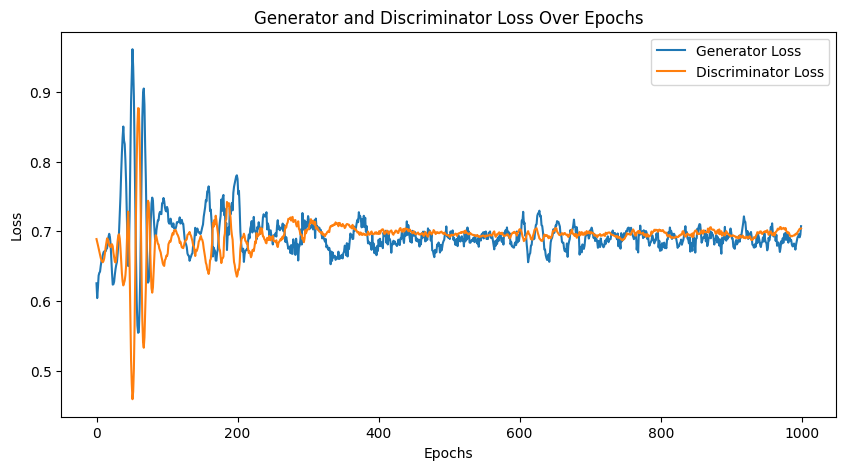

In [7]:
def plot_losses(g_loss, d_loss):
    plt.figure(figsize=(10, 5))
    plt.plot(g_loss, label='Generator Loss')
    plt.plot(d_loss, label='Discriminator Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Generator and Discriminator Loss Over Epochs')
    plt.legend()
    plt.show()
plot_losses(hist.history['g_loss'], hist.history['d_loss'])


In [8]:
imgs = generator.predict(tf.random.normal((7000, 128)))

219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


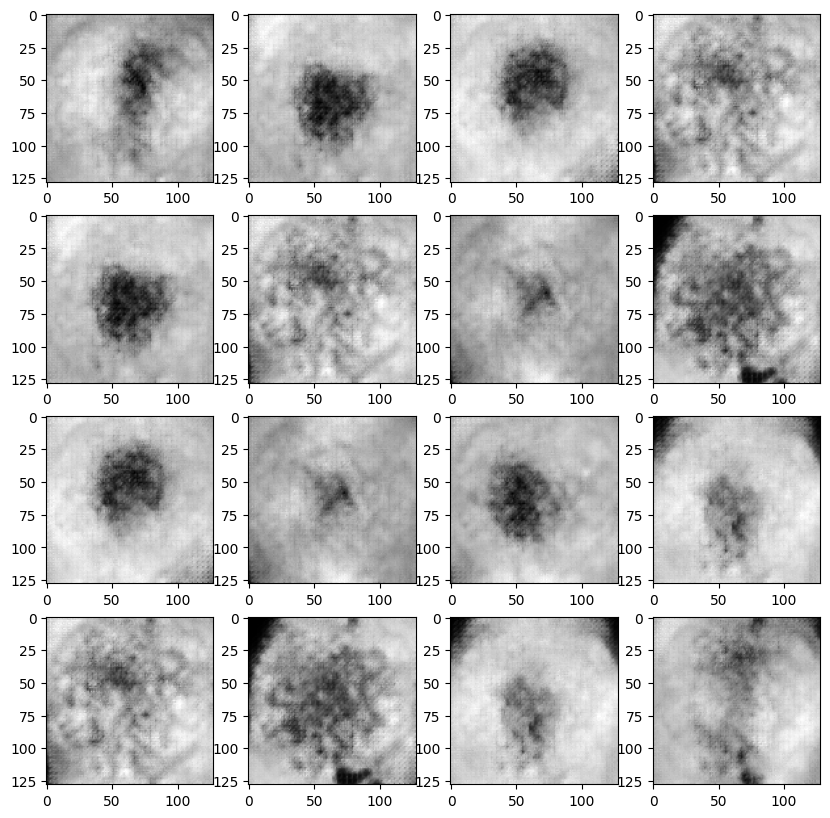

In [9]:
fig, ax = plt.subplots(ncols=4, nrows=4, figsize=(10,10))
for r in range(4):
    for c in range(4):
        ax[r][c].imshow(imgs[(r+1)*(c+1)-1], cmap='gray')

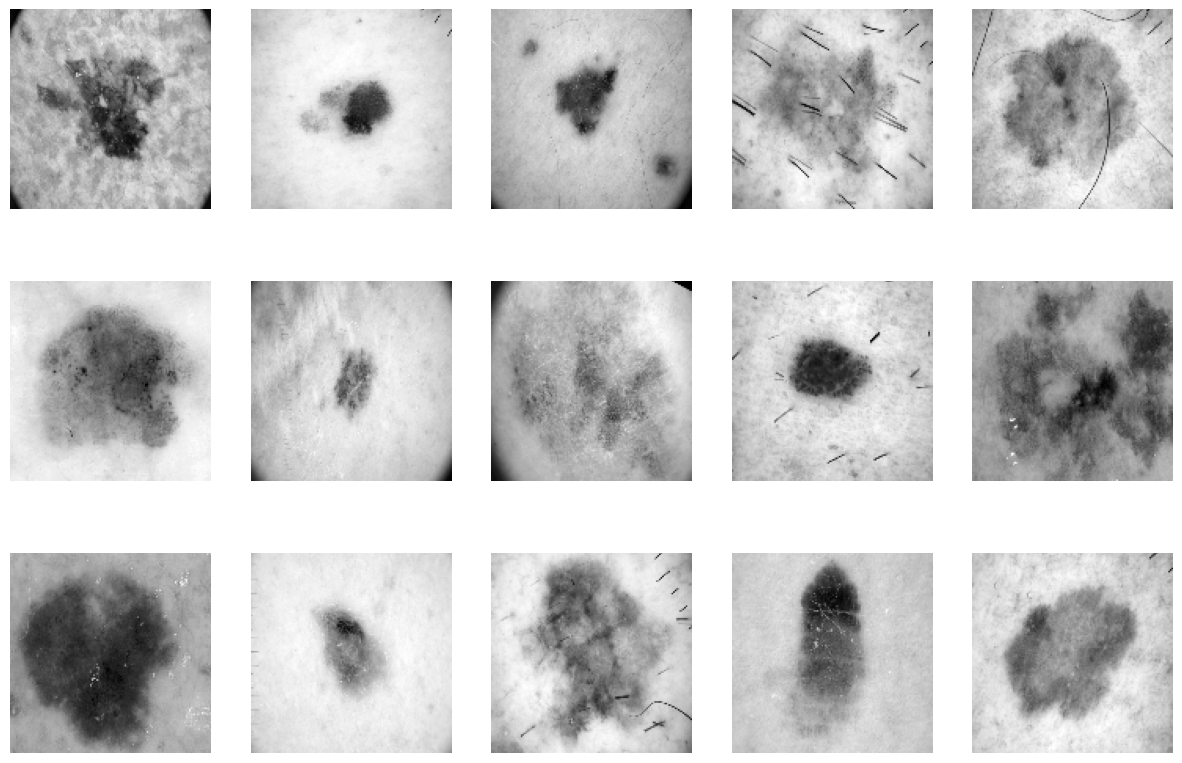

In [11]:
import matplotlib.pyplot as plt

def display_images(images, num_images=15, img_size=(128, 128)):
    plt.figure(figsize=(15, 10))  # Set the figure size
    for i in range(num_images):
        plt.subplot(3, 5, i + 1)  # Create a subplot with 3 rows and 5 columns
        plt.imshow(images[i], cmap='gray')  # Display image in grayscale
        plt.axis('off')  # Turn off axis labels
    plt.show()

# Ensure that we have at least 15 images to display
num_images_to_display = min(15, len(melanoma_images))

# Call the function to display the images
display_images(melanoma_images, num_images=num_images_to_display)


In [12]:
import numpy as np
import os
import cv2

# Step 1: Load and Preprocess NV Images
nv_df = df[df['NV'] == 1]
nv_image_count = len(nv_df)
nv_image_shape = (128, 128, 1)

# Create a memory-mapped array for NV images
nv_images_memmap = np.memmap('nv_images.dat', dtype='float32', mode='w+', shape=(nv_image_count,) + nv_image_shape)

# Function to preprocess a single image
def preprocess_image(img_path):
    image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    image = cv2.resize(image, (128, 128))
    return image / 255.0  # Normalize the image

# Preprocess and store NV images directly in the memory-mapped array
for idx, img_file in enumerate(nv_df['image']):
    img_path = os.path.join(image_folder, img_file + '.jpg')
    nv_images_memmap[idx] = preprocess_image(img_path).reshape(nv_image_shape)

# Flush to save changes and free memory
nv_images_memmap.flush()
del nv_images_memmap

# Reload the memory-mapped array for NV images in read mode
nv_images = np.memmap('nv_images.dat', dtype='float32', mode='r', shape=(nv_image_count,) + nv_image_shape)
print(f"Shape of NV images: {nv_images.shape}")

# Step 2: Combine Original and Generated Images
melanoma_image_count = len(melanoma_images)
generated_image_count = len(imgs)

# Create memory-mapped arrays for generated images
generated_images = np.memmap('generated_images.dat', dtype='float32', mode='w+', shape=(generated_image_count,) + nv_image_shape)
generated_images[:] = imgs.reshape(-1, 128, 128, 1)
generated_images.flush()
del generated_images

# Reload memory-mapped arrays for generated images
generated_images = np.memmap('generated_images.dat', dtype='float32', mode='r', shape=(generated_image_count,) + nv_image_shape)

# Create labels for the images
melanoma_labels = np.ones(melanoma_image_count)  # Label 1 for melanoma (malignant)
nv_labels = np.zeros(nv_image_count)  # Label 0 for NV (benign)
generated_labels = np.ones(generated_image_count)  # Label 1 for generated melanoma images

# Combine images using a memory-mapped array
total_images_count = melanoma_image_count + nv_image_count + generated_image_count
combined_images = np.memmap('combined_images.dat', dtype='float32', mode='w+', shape=(total_images_count,) + nv_image_shape)

# Write images into the combined memory-mapped array
combined_images[:melanoma_image_count] = melanoma_images
combined_images[melanoma_image_count:melanoma_image_count + nv_image_count] = nv_images
combined_images[melanoma_image_count + nv_image_count:] = generated_images

# Flush to save changes and delete temporary references
combined_images.flush()
del nv_images, generated_images

# Reload combined images in read mode
combined_images = np.memmap('combined_images.dat', dtype='float32', mode='r', shape=(total_images_count,) + nv_image_shape)

# Combine labels into a single array (stored in memory as it is smaller)
combined_labels = np.concatenate((melanoma_labels, nv_labels, generated_labels), axis=0)

print(f"Shape of combined images: {combined_images.shape}")
print(f"Shape of combined labels: {combined_labels.shape}")


Shape of NV images: (6705, 128, 128, 1)
Shape of combined images: (14818, 128, 128, 1)
Shape of combined labels: (14818,)


Naive Bayes Model Accuracy: 87.48%
Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.88      0.86      1341
         1.0       0.90      0.87      0.88      1623

    accuracy                           0.87      2964
   macro avg       0.87      0.88      0.87      2964
weighted avg       0.88      0.87      0.88      2964



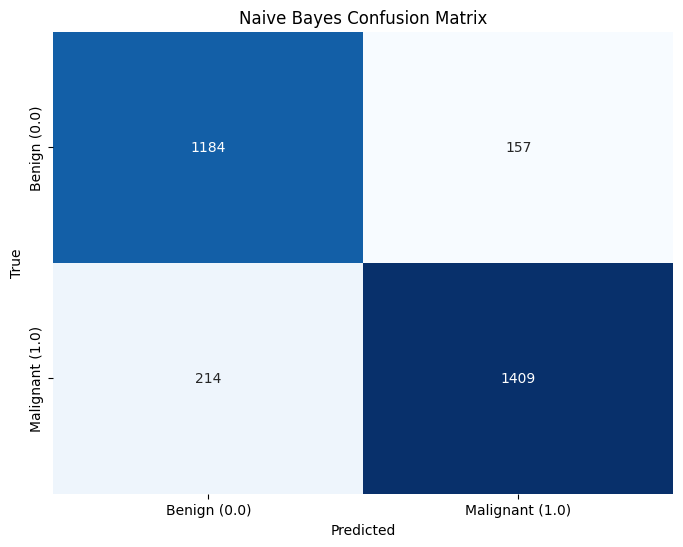

In [14]:
# Step 1: Import required libraries
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Step 2: Assuming combined_images and combined_labels are already defined
# Let's split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    combined_images, combined_labels, test_size=0.2, random_state=42, stratify=combined_labels
)

# Step 3: Flatten the Images
# Reshape each image into a vector (128*128 = 16384 elements)
X_train_flattened = X_train.reshape(X_train.shape[0], -1)
X_test_flattened = X_test.reshape(X_test.shape[0], -1)

# Step 4: Normalize the Data
X_train_flattened = X_train_flattened / 255.0
X_test_flattened = X_test_flattened / 255.0

# Step 5: Train a Naive Bayes Model
# Initialize the model
nb_model = GaussianNB()

# Fit the model on the training data
nb_model.fit(X_train_flattened, y_train)

# Step 6: Evaluate the Model
# Predict on the test set
y_pred_nb = nb_model.predict(X_test_flattened)

# Get accuracy
accuracy_nb = accuracy_score(y_test, y_pred_nb)
print(f"Naive Bayes Model Accuracy: {accuracy_nb * 100:.2f}%")

# Generate a classification report
print("Classification Report:")
print(classification_report(y_test, y_pred_nb))

# Generate and plot the confusion matrix
conf_matrix_nb = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_nb, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Benign (0.0)', 'Malignant (1.0)'],
            yticklabels=['Benign (0.0)', 'Malignant (1.0)'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Naive Bayes Confusion Matrix')
plt.show()


Fitting 5 folds for each of 10 candidates, totalling 50 fits


/opt/conda/lib/python3.10/site-packages/joblib/externals/loky/backend/fork_exec.py:38: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid = os.fork()
/opt/conda/lib/python3.10/site-packages/joblib/externals/loky/backend/fork_exec.py:38: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid = os.fork()


Best Parameters: {'var_smoothing': 0.09999999999999999}
Best Cross-Validation Accuracy: 0.88
Test Accuracy with Best Parameters: 86.88%
Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.86      0.86      1341
         1.0       0.89      0.87      0.88      1623

    accuracy                           0.87      2964
   macro avg       0.87      0.87      0.87      2964
weighted avg       0.87      0.87      0.87      2964



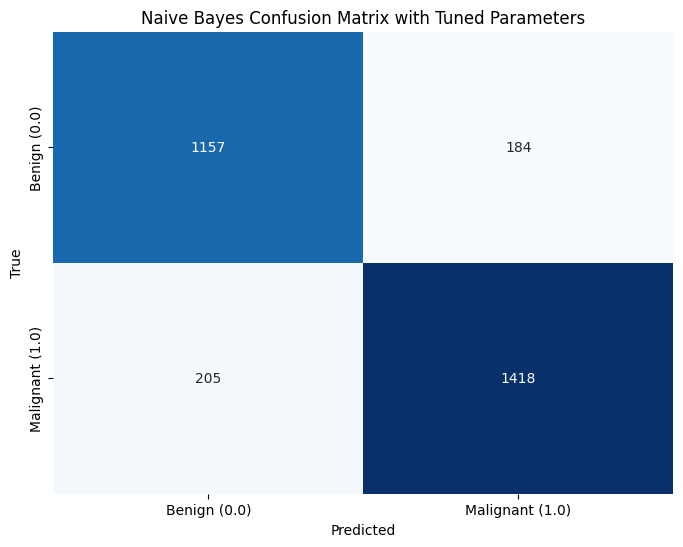

In [15]:
# Step 1: Import necessary libraries for tuning
from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import GaussianNB

# Step 2: Define the parameter grid
param_grid = {
    'var_smoothing': np.logspace(-9, 0, 10)  # A range of values to test for var_smoothing
}

# Step 3: Initialize the GaussianNB model
nb_model = GaussianNB()

# Step 4: Set up GridSearchCV
grid_search = GridSearchCV(
    estimator=nb_model, 
    param_grid=param_grid, 
    cv=5,  # 5-fold cross-validation
    scoring='accuracy',  # Evaluate the model based on accuracy
    verbose=2, 
    n_jobs=-1  # Use all available CPU cores
)

# Step 5: Fit the model using GridSearchCV on the flattened training data
grid_search.fit(X_train_flattened, y_train)

# Step 6: Get the best parameters and best score
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.2f}")

# Step 7: Evaluate the model with the best parameters on the test set
best_nb_model = grid_search.best_estimator_
y_pred_nb = best_nb_model.predict(X_test_flattened)

# Calculate test accuracy
accuracy_nb = accuracy_score(y_test, y_pred_nb)
print(f"Test Accuracy with Best Parameters: {accuracy_nb * 100:.2f}%")

# Step 8: Generate the classification report for the tuned model
print("Classification Report:")
print(classification_report(y_test, y_pred_nb))

# Step 9: Generate and plot the confusion matrix
conf_matrix_nb = confusion_matrix(y_test, y_pred_nb)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_nb, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Benign (0.0)', 'Malignant (1.0)'],
            yticklabels=['Benign (0.0)', 'Malignant (1.0)'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Naive Bayes Confusion Matrix with Tuned Parameters')
plt.show()


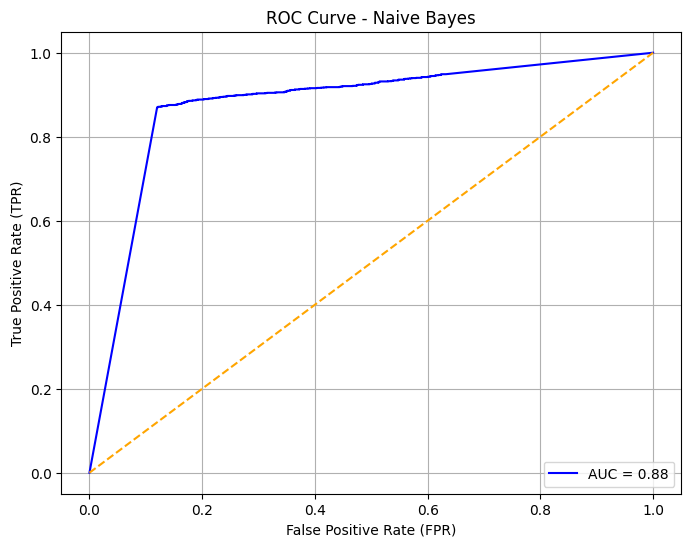

In [16]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get predicted probabilities for class 1
y_prob_nb = best_nb_model.predict_proba(X_test_flattened)[:, 1]

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_nb)
roc_auc = roc_auc_score(y_test, y_prob_nb)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}', color='blue')
plt.plot([0, 1], [0, 1], color='orange', linestyle='--')
plt.title('ROC Curve - Naive Bayes')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc="lower right")
plt.grid()
plt.show()


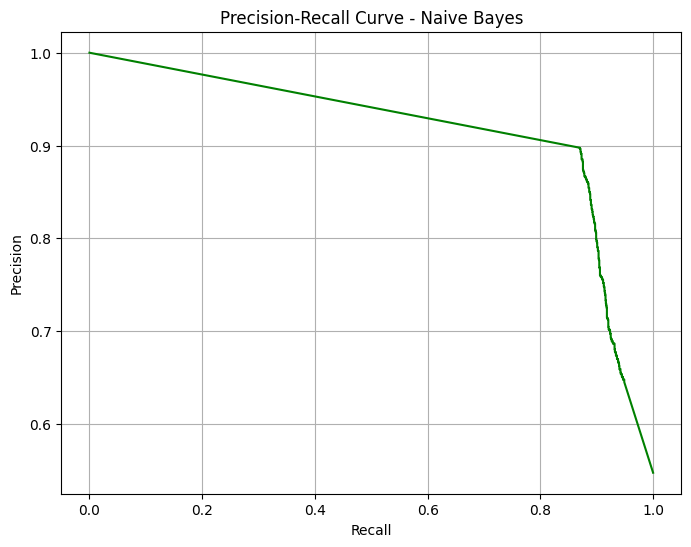

In [17]:
from sklearn.metrics import precision_recall_curve

# Calculate Precision-Recall curve
precision, recall, _ = precision_recall_curve(y_test, y_prob_nb)

# Plot Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='green')
plt.title('Precision-Recall Curve - Naive Bayes')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.grid()
plt.show()


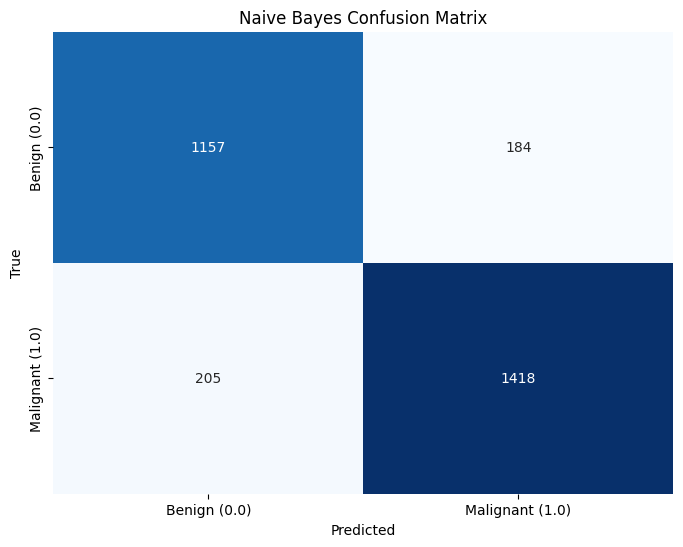

In [18]:
# Confusion Matrix (Already generated but adding here for context)
conf_matrix_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_nb, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Benign (0.0)', 'Malignant (1.0)'],
            yticklabels=['Benign (0.0)', 'Malignant (1.0)'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Naive Bayes Confusion Matrix')
plt.show()


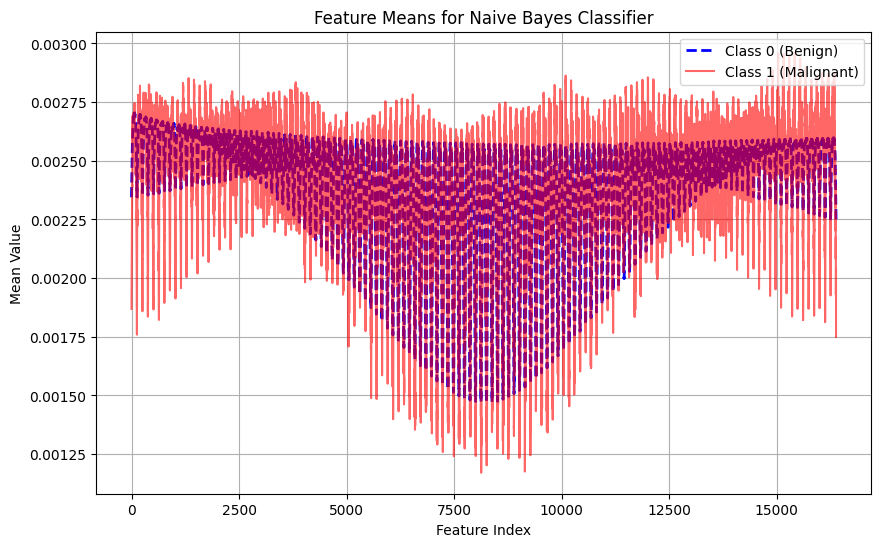

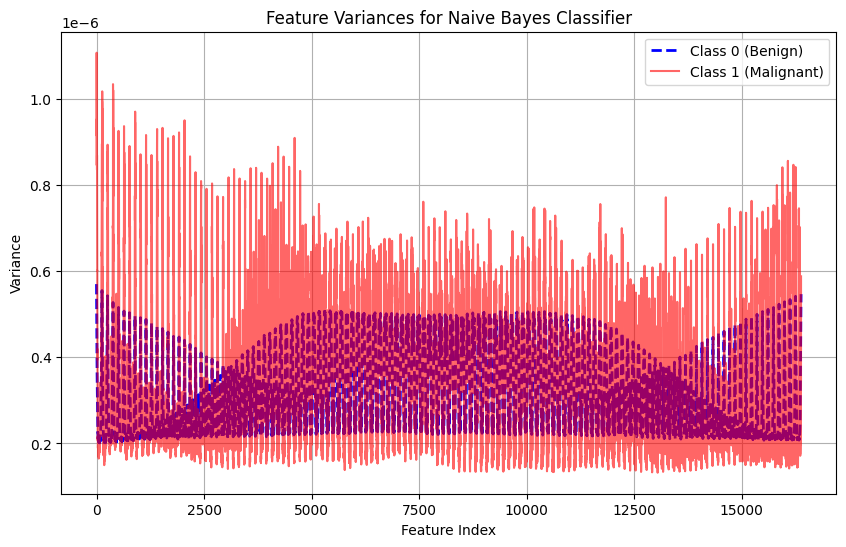

In [21]:
import matplotlib.pyplot as plt

# Get means and variances of each feature from the Naive Bayes model
means = best_nb_model.theta_
variances = best_nb_model.var_

# Plot feature means for both classes
plt.figure(figsize=(10, 6))
plt.plot(means[0], label='Class 0 (Benign)', linestyle='--', color='blue', linewidth=2)
plt.plot(means[1], label='Class 1 (Malignant)', color='red', alpha=0.6)
plt.title('Feature Means for Naive Bayes Classifier')
plt.xlabel('Feature Index')
plt.ylabel('Mean Value')
plt.legend(loc='upper right')
plt.grid()
plt.show()

# Plot feature variances for both classes
plt.figure(figsize=(10, 6))
plt.plot(variances[0], label='Class 0 (Benign)', linestyle='--', color='blue', linewidth=2)
plt.plot(variances[1], label='Class 1 (Malignant)', color='red', alpha=0.6)
plt.title('Feature Variances for Naive Bayes Classifier')
plt.xlabel('Feature Index')
plt.ylabel('Variance')
plt.legend(loc='upper right')
plt.grid()
plt.show()
